# 07 – Tulokset

Muistio kokoaa projektin tulokset. Se ei aja malleja vaan lukee valmiit tulokset kansiosta `results/` (muistiot 05, 06, 09 ja 11). Raportin englanninkieliset kuvat tekee muistio 08.

## Päälöydökset

1. **Puolueet erottuvat puheissaan toisistaan selvemmin, ja muutos tapahtuu kaudella 2023–27.** Polarisaatio on 0,39 → 0,45 → 0,56. Ensimmäinen nousu selittyy osin puheiden pitenemisellä, toinen ei. Leave-out-mittarin vuosisarja on lähes tasainen 2015–2022 ja nousee 2023. Tulos kestää satunnaistestin, toisen mittarin sekä ministerien ja tyylisanojen poistamisen. (osio 1)
2. **Ero ei johdu vain siitä, että puolueet puhuvat eri aiheista.** Erottuvuus kasvaa myös saman teeman puheissa: maahanmuutto, ilmasto ja turvallisuus. (osio 2)
3. **Eduskunta on jakautunut kahdeksi blokiksi.** KOK, PS ja KD puhuvat samankaltaisesti joka kaudella, myös oppositiossa. VAS, SDP ja VIHR ovat kannoiltaan lähellä toisiaan mutta puhuvat eri tavoin. Kaudella 2023–27 ideologinen jako ja hallitusraja osuvat yksiin, ja rajan yli olevat parit erottuvat eniten (0,66). (osio 3)

Toissijainen tulos: puolueiden sisäinen monimuotoisuus ei ole kaventunut. Puolueet ovat erkaantuneet toisistaan, mutta edustajat eivät ole tulleet samankaltaisemmiksi. (osio 4)

**Rajoitus, joka koskee kaikkia tuloksia:** kausia on kolme, ja jokaisella on eri hallituspohja. Ajallista trendiä ei voi erottaa siitä, millainen hallitus kaudella oli. Kausi 2023–27 on kesken (aineisto 23.9.2026 asti).

## Menetelmä lyhyesti

Tarkempi kuvaus ja käsitteiden englanninkieliset vastineet ovat muistiossa 05.

- **Luokittelija** arvaa yksittäisen puheen perusteella puhujan puolueen. Jokaiselle kaudelle opetetaan oma malli kahdeksalle puolueelle, jotka ovat eduskunnassa kaikilla kausilla. Piirteinä ovat siivottujen puheiden sanat ja sanaparit (26 209 fraasia, TF-IDF).
- **Harhojen torjunta:** opetus ja testaus jaetaan edustajittain, ja jokainen puolue saa 300 opetuspuhetta. Ajo toistetaan 8 kertaa 80 %:lla edustajista (vaihteluväli = toistojen 10.–90. persentiili). Neljässä satunnaistestissä puoluenimikkeet sekoitetaan.
- **Erottuvuus** (*separability*) d = 2·AUC − 1 kertoo, kuinka hyvin malli erottaa kahden puolueen puheet (0 = ei lainkaan, 1 = aina). **Polarisaatio** (*polarisation*) on erottuvuuden keskiarvo 28 puolueparin yli.
- **Hallitus** tarkoittaa kunkin kauden pääministerin hallitusta (`config.MAIN_GOVERNMENT`). PS lasketaan hallitukseen koko kaudelle 2015–19.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
import config

pd.set_option("display.width", 160)

TULOKSET = "../results/"
KUVAT = "../reports/figures/"
PUOLUEET = config.MAIN_PARTIES          # 8 puoluetta ilman Sinisiä
VARIT = config.PARTY_COLORS
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]

yhteenveto = pd.read_csv(TULOKSET + "party_summary.csv")
parit = pd.read_csv(TULOKSET + "party_pairwise.csv")
monimuotoisuus = pd.read_csv(TULOKSET + "party_diversity.csv")
profiilit = pd.read_csv(TULOKSET + "party_mp_profiles.csv")
hallitus = pd.read_csv(TULOKSET + "government_summary.csv")
ilman_ministereita = pd.read_csv(TULOKSET + "party_nominister_summary.csv")
ilman_tyylisanoja = pd.read_csv(TULOKSET + "party_nostyle_summary.csv")
leaveout = pd.read_csv(TULOKSET + "leaveout_party_pairs_term.csv")
leaveout_vuosi = pd.read_csv(TULOKSET + "leaveout_party_pairs_year.csv")
leaveout_hallitus_vuosi = pd.read_csv(TULOKSET + "leaveout_gov_year.csv")
teemaparit = pd.read_csv(TULOKSET + "teemat_pairwise.csv")
vaalikoneparit = pd.read_csv(TULOKSET + "vaalikone_pair_comparison.csv")


def vali(arvot):
    """Keskiarvo sekä 10. ja 90. persentiili."""
    return pd.Series({"ka": arvot.mean(), "p10": arvot.quantile(0.1), "p90": arvot.quantile(0.9)})

## 1. Puolueet erottuvat selvemmin, ja muutos tapahtuu kaudella 2023–27

Taulukossa on polarisaatio päämallilla ja kolmella tarkistuksella. Sarake *hallitus vs. oppositio* on kontrollitehtävä: malli arvaa puolueen sijasta puhujan hallitusaseman.

In [2]:
def polarisaatio_kausittain(taulu, sarja="real"):
    return taulu[taulu["series"] == sarja].groupby("term")["polarisation"].mean()


polarisaatio = pd.DataFrame({
    "puolueet": polarisaatio_kausittain(yhteenveto),
    "puolueet, satunnainen": polarisaatio_kausittain(yhteenveto, "random"),
    "hallitus vs. oppositio": polarisaatio_kausittain(hallitus),
    "puolueet ilman ministereitä": polarisaatio_kausittain(ilman_ministereita),
    "puolueet ilman tyylisanoja": polarisaatio_kausittain(ilman_tyylisanoja),
}).rename_axis("kausi")
polarisaatio.round(3)

,puolueet,"puolueet, satunnainen",hallitus vs. oppositio,puolueet ilman ministereitä,puolueet ilman tyylisanoja
kausi,,,,,
2015-2019,0.391,-0.003,0.347,0.387,0.386
2019-2023,0.451,0.001,0.467,0.463,0.451
2023-2027,0.558,-0.004,0.519,0.547,0.547


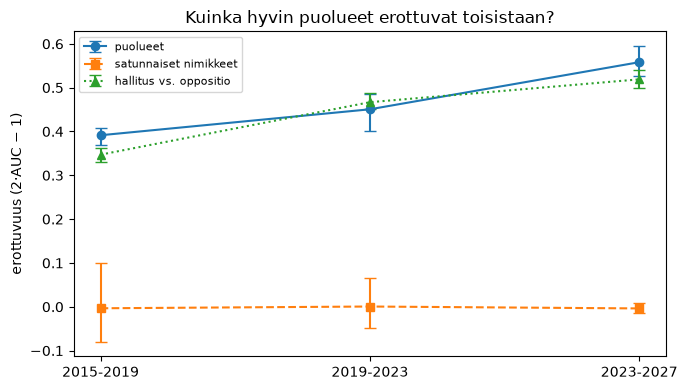

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(KAUDET))

for sarja, nimi, tyyli in [("real", "puolueet", "o-"), ("random", "satunnaiset nimikkeet", "s--")]:
    osa = yhteenveto[yhteenveto["series"] == sarja]
    luvut = osa.groupby("term")["polarisation"].apply(vali).unstack().reindex(KAUDET)
    ax.errorbar(x, luvut["ka"], yerr=[luvut["ka"] - luvut["p10"], luvut["p90"] - luvut["ka"]],
                fmt=tyyli, capsize=4, label=nimi)

osa = hallitus[hallitus["series"] == "real"]
luvut = osa.groupby("term")["polarisation"].apply(vali).unstack().reindex(KAUDET)
ax.errorbar(x, luvut["ka"], yerr=[luvut["ka"] - luvut["p10"], luvut["p90"] - luvut["ka"]],
            fmt="^:", capsize=4, label="hallitus vs. oppositio")

ax.set_xticks(x)
ax.set_xticklabels(KAUDET)
ax.set_ylabel("erottuvuus (2·AUC − 1)")
ax.set_title("Kuinka hyvin puolueet erottuvat toisistaan?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(KUVAT + "tulokset_polarisaatio.png")
plt.show()

**Tulkinta.**
- Polarisaatio kasvaa joka kaudella: 0,39 → 0,45 → 0,56. Ensimmäisen ja viimeisen kauden vaihteluvälit eivät mene päällekkäin (0,37–0,41 ja 0,53–0,60).
- Satunnaistestissä polarisaatio on noin 0. Menetelmä ei siis tuota eroja sinne, missä niitä ei ole.
- Tulos ei muutu, kun ministerien puheet poistetaan. Se ei myöskään muutu, kun poistetaan tyylisanat (adverbit, partikkelit ja puhetekoverbit, noin 12 % sanojen esiintymistä): 0,39 → 0,45 → 0,55.
- Hallitus–oppositio-erottuvuus kasvaa samaa tahtia. Osa puolue-eroista on siis hallitusaseman eroa (osio 3).

### Toinen mittari ja vuosittainen kehitys

Gentzkowin ym. leave-out-mittari (muistio 06) on kirjallisuuden vakiomenetelmä. π on todennäköisyys arvata puhujan puolue oikein yhden sanaparin perusteella (0,5 = ei eroa). Mittari lasketaan myös vuosittain, joten sillä näkee, milloin muutos tapahtuu.

In [4]:
kausittain = leaveout.groupby("term")[["pi", "pi_random"]].mean()
for kausi in KAUDET:
    luokittelija = parit[(parit["term"] == kausi) & (parit["series"] == "real")].groupby(["a", "b"])["d"].mean()
    gentzkow = leaveout[leaveout["term"] == kausi].set_index(["a", "b"])["pi"]
    yhdessa = pd.concat([luokittelija, gentzkow], axis=1, join="inner")
    kausittain.loc[kausi, "rho luokittelijaan"] = yhdessa["d"].corr(yhdessa["pi"], method="spearman")
kausittain.columns = ["π puolueparit", "π satunnainen", "rho luokittelijaan"]
kausittain.round(3)

,π puolueparit,π satunnainen,rho luokittelijaan
term,,,
2015-2019,0.520,0.495,0.957
2019-2023,0.525,0.496,0.891
2023-2027,0.532,0.494,0.939


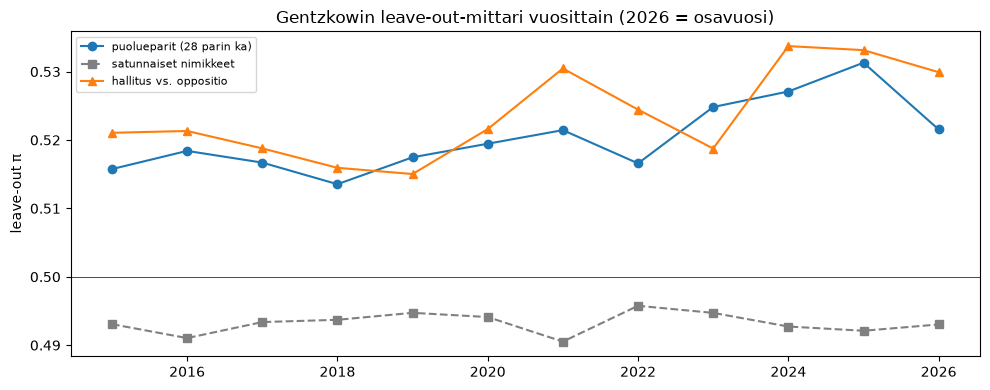

In [5]:
vuosittain = pd.read_csv(TULOKSET + "leaveout_party_pairs_year.csv")
vuosittain_hallitus = pd.read_csv(TULOKSET + "leaveout_gov_year.csv")

puolueet_vuosi = vuosittain.groupby("year")[["pi", "pi_random"]].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(puolueet_vuosi.index, puolueet_vuosi["pi"], "o-", label="puolueparit (28 parin ka)")
ax.plot(puolueet_vuosi.index, puolueet_vuosi["pi_random"], "s--", color="grey", label="satunnaiset nimikkeet")
ax.plot(vuosittain_hallitus["year"], vuosittain_hallitus["pi"], "^-", label="hallitus vs. oppositio")
ax.axhline(0.5, color="black", linewidth=0.5)
ax.set_ylabel("leave-out π")
ax.set_title("Gentzkowin leave-out-mittari vuosittain (2026 = osavuosi)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(KUVAT + "tulokset_leaveout_vuosittain.png")
plt.show()

**Tulkinta.** Leave-out-mittari kasvaa samaan suuntaan (0,520 → 0,525 → 0,532), ja se järjestää puolueparit lähes samoin kuin luokittelija (rho 0,89–0,95). Vuosisarja tarkentaa kuvaa:
- 2015–2022 π on lähes tasainen (0,514–0,522).
- 2023–2025 π nousee (0,525–0,531).
- 2026 on osavuosi (tammi–syyskuu), ja sen arvo on epävarmempi.

Kyse ei siis ole tasaisesta kymmenen vuoden trendistä vaan tasonmuutoksesta Orpon hallituksen kaudella. Luokittelijan kausiluvut ovat tämän kanssa yhdenmukaisia: suurempi hyppy on 2019–23 → 2023–27 (+0,11) kuin 2015–19 → 2019–23 (+0,06). Leave-out-mittarin absoluuttiset erot ovat pieniä, koska yksi sanapari kertoo vähän; järjestys on olennainen.

### Puheiden pituus

Luokittelija arvaa puolueen yhdestä puheesta, joten pitkä puhe on helpompi tunnistaa kuin lyhyt. Jos puheet pitenevät, erottuvuus kasvaa, vaikka puolueiden kieli ei muuttuisi. Leave-out-mittari ei ole herkkä tälle, koska se mitataan yhtä sanaparia kohti (Gentzkow ym. 2019, s. 1313–1314). Tarkistus: erottuvuus lasketaan erikseen eripituisille puheille muistion 05 testiennusteista (laskenta muistion 11 liitteessä).

In [6]:
pituus = pd.read_csv(TULOKSET + "pituus_erottuvuus.csv")
print("Puheiden mediaanipituus (sanaa siivouksen jälkeen):", pituus.groupby("term")["median_length"].first().to_dict())
pituus.pivot(index="length", columns="term", values="d").reindex(["alle 50", "50–100", "100–200", "yli 200"]).round(2)

Puheiden mediaanipituus (sanaa siivouksen jälkeen): {'2015-2019': 88.0, '2019-2023': 111.0, '2023-2027': 105.0}


term,2015-2019,2019-2023,2023-2027
length,,,
alle 50,0.27,0.25,0.42
50–100,0.35,0.41,0.52
100–200,0.39,0.41,0.50
yli 200,0.45,0.50,0.63


**Tulkinta.** Puheet pitenivät kaudesta 2015–19 kauteen 2019–23 (mediaani 88 → 111 sanaa), mutta eivät sen jälkeen (105).
- **Saman pituisten puheiden sisällä** erottuvuus kasvaa kaudesta 2015–19 kauteen 2019–23 vain vähän (−0,02…+0,06), mutta kauteen 2023–27 selvästi joka pituusluokassa (+0,09…+0,18).
- Ensimmäinen nousu (0,39 → 0,45) on siis osin puheiden pitenemistä. Toinen nousu (0,45 → 0,56) ei ole.
- Tämä sopii leave-out-mittarin vuosisarjaan, joka on tasainen 2015–2022 ja nousee 2023. Päälöydöksen muotoilu "muutos tapahtuu kaudella 2023–27" on siis perusteltu.

## 2. Ero ei johdu vain aiheista

Kasvava erottuvuus voisi johtua siitä, että puolueet puhuvat yhä enemmän eri asioista (aiheiden omistajuus, *issue ownership*). Muistio 11 laskee erottuvuuden vain saman teeman puheista, jolloin aiheen valinta ei voi selittää eroja. Teemat ja hakusanat ovat Gronowin ja Malkamäen (2024) Twitter-tutkimuksesta. Mukana ovat kuusi suurinta puoluetta (15 paria), koska RKP:llä ja KD:llä teemapuheita on liian vähän.

In [7]:
TEEMAT = ["kaikki", "maahanmuutto", "ilmasto", "turvallisuus"]
osa = teemaparit[(teemaparit["malli"] == "party") & teemaparit["teema"].isin(TEEMAT)]
keskiarvot = osa.groupby(["teema", "term", "a", "b"])["d"].mean().reset_index()

rivit = []
for teema, ryhma in keskiarvot.groupby("teema"):
    kausia = ryhma.groupby(["a", "b"])["term"].nunique()
    yhteiset = kausia[kausia == 3].index          # parit, jotka voidaan laskea kaikilla kausilla
    ryhma = ryhma.set_index(["a", "b"]).loc[yhteiset]
    rivi = ryhma.groupby("term")["d"].mean()
    rivi.name = teema
    rivit.append(rivi)
pd.DataFrame(rivit).loc[TEEMAT, KAUDET].round(2)

term,2015-2019,2019-2023,2023-2027
kaikki,0.38,0.47,0.58
maahanmuutto,0.43,0.46,0.55
ilmasto,0.34,0.50,0.56
turvallisuus,0.30,0.31,0.45


**Tulkinta.** Erottuvuus kasvaa jokaisen teeman sisällä, ja taso on suunnilleen sama kuin kaikissa puheissa. Puolueet eivät siis vain puhu eri asioista, vaan puhuvat samasta asiasta yhä eri tavalla (kehystys, *framing*). Tämä tukee polarisaatiotulkintaa. Osa kehystyksen erosta voi silti olla roolia: hallitus puolustaa esityksiään ja oppositio arvostelee niitä samassa keskustelussa.

Suunnat sopivat yhteen Gronowin ja Malkamäen Twitter-tulosten kanssa: esimerkiksi ilmastossa PS:n ja vasemmisto-vihreiden ero kaksinkertaistuu kaudella 2019–23, samaan aikaan kuin ilmasto alkoi Twitterissä polarisoitua. Yksityiskohdat ovat muistiossa 11.

## 3. Kaksi blokkia

### Puolueparit ja puoluekartta

Erottuvuus jokaiselle puolueparille. Kartta tehdään klassisella moniulotteisella skaalauksella (MDS): lähekkäiset puolueet sekoittuvat mallissa helposti. Akseleilla ei ole valmista merkitystä, ja akselien suunnat valitaan niin, että kartta on mahdollisimman samassa asennossa kuin edellisellä kaudella.

In [8]:
def erottuvuusmatriisi(kausi):
    """8 x 8 -taulukko puolueparien erottuvuudesta (toistojen keskiarvo)."""
    osa = parit[(parit["term"] == kausi) & (parit["series"] == "real")]
    keskiarvot = osa.groupby(["a", "b"])["d"].mean().unstack().reindex(index=PUOLUEET, columns=PUOLUEET)
    matriisi = keskiarvot.fillna(0) + keskiarvot.T.fillna(0)      # symmetriseksi, lävistäjä 0
    return matriisi.rename_axis(index=None, columns=None)


erottuvuusmatriisi("2023-2027").round(2)

,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
VAS,0.00,0.46,0.40,0.71,0.83,0.71,0.75,0.76
SDP,0.46,0.00,0.56,0.39,0.71,0.46,0.49,0.62
VIHR,0.40,0.56,0.00,0.67,0.75,0.54,0.70,0.76
KESK,0.71,0.39,0.67,0.00,0.74,0.47,0.57,0.59
RKP,0.83,0.71,0.75,0.74,0.00,0.26,0.48,0.63
KD,0.71,0.46,0.54,0.47,0.26,0.00,0.13,0.25
KOK,0.75,0.49,0.70,0.57,0.48,0.13,0.00,0.23
PS,0.76,0.62,0.76,0.59,0.63,0.25,0.23,0.00


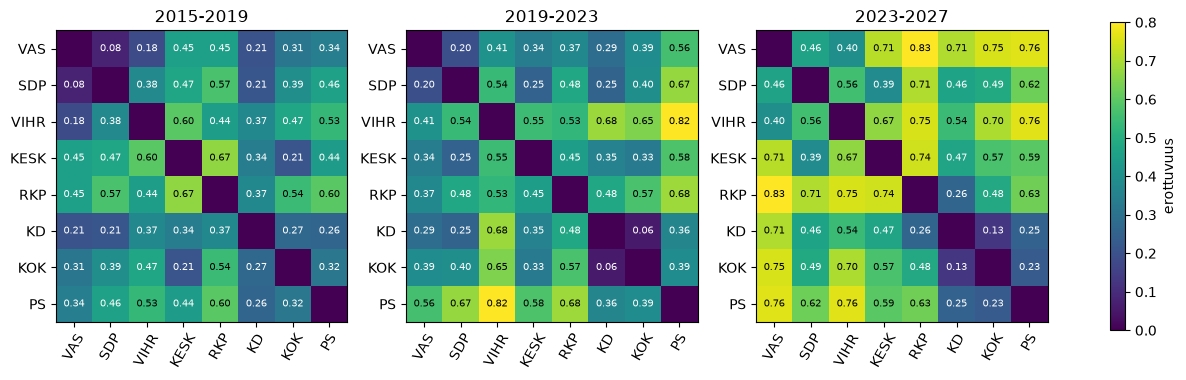

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for i, kausi in enumerate(KAUDET):
    matriisi = erottuvuusmatriisi(kausi)
    ax[i].imshow(matriisi.values, cmap="viridis", vmin=0, vmax=0.8)
    ax[i].set_xticks(range(len(PUOLUEET)))
    ax[i].set_xticklabels(PUOLUEET, rotation=60)
    ax[i].set_yticks(range(len(PUOLUEET)))
    ax[i].set_yticklabels(PUOLUEET)
    for r in range(len(PUOLUEET)):
        for s in range(len(PUOLUEET)):
            if r != s:
                arvo = matriisi.values[r, s]
                vari = "white" if arvo < 0.5 else "black"
                ax[i].text(s, r, f"{arvo:.2f}", ha="center", va="center", fontsize=7, color=vari)
    ax[i].set_title(kausi)
fig.colorbar(ax[-1].images[0], ax=ax, shrink=0.8, label="erottuvuus")
plt.savefig(KUVAT + "tulokset_parit.png", bbox_inches="tight")
plt.show()

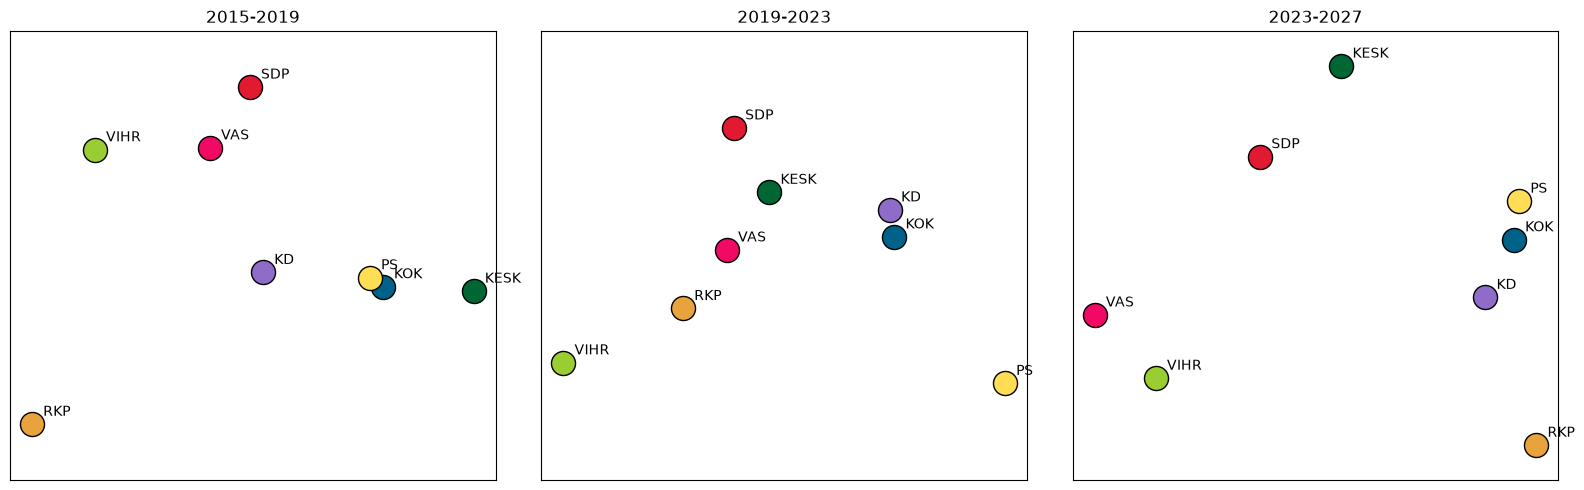

In [10]:
def klassinen_mds(etaisyydet):
    """Klassinen (Torgerson) MDS kahteen ulottuvuuteen."""
    D2 = np.asarray(etaisyydet) ** 2
    n = len(D2)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    ominaisarvot, ominaisvektorit = np.linalg.eigh(B)
    suurimmat = np.argsort(ominaisarvot)[::-1][:2]
    return ominaisvektorit[:, suurimmat] * np.sqrt(np.clip(ominaisarvot[suurimmat], 0, None))


fig, ax = plt.subplots(1, 3, figsize=(16, 5))
edellinen = None
for i, kausi in enumerate(KAUDET):
    sijainnit = klassinen_mds(erottuvuusmatriisi(kausi).values)

    # käännetään akselit samaan suuntaan kuin edellisellä kaudella
    if edellinen is not None:
        for akseli in range(2):
            if np.corrcoef(sijainnit[:, akseli], edellinen[:, akseli])[0, 1] < 0:
                sijainnit[:, akseli] = -sijainnit[:, akseli]
    edellinen = sijainnit

    for j, puolue in enumerate(PUOLUEET):
        x, y = sijainnit[j]
        ax[i].scatter(x, y, s=300, color=VARIT[puolue], edgecolor="black")
        ax[i].annotate(puolue, (x, y), xytext=(8, 6), textcoords="offset points")
    ax[i].set_title(kausi)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.savefig(KUVAT + "tulokset_puoluekartta.png")
plt.show()

**Kartan tulkinta.**
- **2015–19:** hallituspuolueet KESK, KOK ja PS ovat lähekkäin, ja KD on niiden lähellä.
- **2019–23:** PS on muista erillään, ja KOK ja KD ovat yhdessä.
- **2023–27:** KOK, PS ja KD muodostavat tiiviin ryhmän (keskinäinen erottuvuus 0,13–0,25). VAS ja VIHR ovat vastakkaisella laidalla, ja SDP ja KESK ovat muista erillään.
- RKP on joka kaudella muista erillään. Tämä johtuu todennäköisesti aiheista (ruotsin kieli, Vaasa, koulutus; muistio 10) eikä vastakkaisista kannoista.

Kaksiulotteinen kartta on likiarvo: taulukon luvut ovat tarkempia kuin etäisyydet kartalla.

### Hallitus, oppositio ja ideologinen ryhmä

Parit jaetaan kolmeen ryhmään kunkin kauden hallituksen mukaan: molemmat hallituksessa, molemmat oppositiossa, tai toinen kummallakin puolella (*rajan yli*).

In [11]:
def parin_ryhma(kausi, a, b):
    hallitus = config.MAIN_GOVERNMENT[kausi]
    if a in hallitus and b in hallitus:
        return "hallitus–hallitus"
    if a not in hallitus and b not in hallitus:
        return "oppositio–oppositio"
    return "rajan yli"


oikeat_parit = parit[parit["series"] == "real"].copy()
oikeat_parit["ryhmä"] = [parin_ryhma(kausi, a, b)
                         for kausi, a, b in zip(oikeat_parit["term"], oikeat_parit["a"], oikeat_parit["b"])]

keskiarvot = oikeat_parit.groupby(["term", "ryhmä"])["d"].mean().unstack().round(2)
yksittaiset_parit = oikeat_parit.drop_duplicates(["term", "a", "b"])      # yksi rivi per pari (ei toistoja)
pareja = yksittaiset_parit.groupby(["term", "ryhmä"]).size().unstack()
print("Erottuvuus ryhmittäin:")
display(keskiarvot)
print("Pareja ryhmässä:")
display(pareja)

Erottuvuus ryhmittäin:


ryhmä,hallitus–hallitus,oppositio–oppositio,rajan yli
term,,,
2015-2019,0.32,0.33,0.45
2019-2023,0.41,0.27,0.51
2023-2027,0.33,0.53,0.65


Pareja ryhmässä:


ryhmä,hallitus–hallitus,oppositio–oppositio,rajan yli
term,,,
2015-2019,3,10,15
2019-2023,10,3,15
2023-2027,6,6,16


Toinen näkökulma on ideologinen ryhmä. KOK, PS ja KD olivat hallituksessa 2015–19 (KD ei), oppositiossa 2019–23 ja hallituksessa 2023–27. Taulukko vertaa ryhmien keskinäisiä pareja puheissa ja Ylen vaalikoneessa (muistio 09). **Sija** 1 on lähin ja 28 kaukaisin pari. **Sijaero** = sija puheissa − sija vaalikoneessa: negatiivinen luku tarkoittaa, että parit puhuvat samankaltaisemmin kuin niiden kannat antavat odottaa.

In [12]:
BLOKIT = {"KOK–PS–KD": {"KOK", "PS", "KD"}, "VAS–SDP–VIHR": {"VAS", "SDP", "VIHR"}}
rivit = []
for nimi, puolueet in BLOKIT.items():
    for vuosi, ryhma in vaalikoneparit.groupby("vuosi"):
        mukana = ryhma["pari"].apply(lambda pari: set(pari.split("–")) <= puolueet)
        osa = ryhma[mukana]
        rivit.append({"ryhmä": nimi, "vaalikone": vuosi,
                      "sija vaalikoneessa": osa["sija vaalikone"].mean(),
                      "sija puheissa": osa["sija puheet"].mean(),
                      "sijaero": osa["sijaero"].mean()})
pd.DataFrame(rivit).set_index(["ryhmä", "vaalikone"]).round(1)

sija vaalikoneessa  sija puheissa  sijaero
ryhmä        vaalikone                                            
KOK–PS–KD    2015                     16.3            7.3     -9.0
             2019                     14.3            7.0     -7.3
             2023                     12.0            2.0    -10.0
VAS–SDP–VIHR 2015                      5.0            5.7      0.7
             2019                      5.0           11.7      6.7
             2023                      5.7            8.7      3.0

**Tulkinta.**
- **Hallitusasema ei yksin selitä samankaltaista puhetta.** Kaudella 2019–23 oppositio (KOK, PS, KD) puhui yhtenäisemmin (0,27) kuin viiden puolueen hallitus (0,41). Kaudella 2023–27 tilanne kääntyi: hallitus puhuu yhtenäisesti (0,33) ja oppositio hajanaisesti (0,53).
- **Samankaltainen puhe seuraa ideologista ryhmää.** KOK, PS ja KD puhuvat joka kaudella samankaltaisemmin kuin niiden kannat antavat odottaa (sijaero −9, −7 ja −10), myös oppositiossa. VAS, SDP ja VIHR ovat kannoiltaan lähimpiä pareja (sija noin 5), mutta ne puhuvat keskenään eri tavoin.
- **Kaudella 2023–27 ideologinen jako ja hallitusraja osuvat ensimmäistä kertaa yksiin.** Oikeiston ryhmä on hallituksessa, ja sen puolueparit ovat vasemmisto-vihreistä kauimpana. Siksi rajan yli olevien parien erottuvuus hyppää (0,51 → 0,65), ja tämä selittää osion 1 tasonmuutoksen.

## 4. Toissijainen: puolueiden sisäinen monimuotoisuus

**Edustajaprofiili** on mallin puoluetodennäköisyyksien keskiarvo 20 edustajan puheesta. **Hajonta** kertoo, kuinka paljon puolueen edustajien profiilit vaihtelevat puolueen keskipisteen ympärillä, ja se on korjattu satunnaisvaihtelun osalta. **Suhteellinen hajonta** jakaa sen puolueiden keskipisteiden välisellä etäisyydellä. Mukana ovat edustajat, joilla on kaudella vähintään 40 puhetta.

In [13]:
oikeat = monimuotoisuus[monimuotoisuus["series"] == "real"]

kaudittain = oikeat.groupby("term")[["diversity_naive", "diversity", "diversity_relative"]].mean().round(3)
kaudittain.columns = ["naiivi hajonta", "kohinakorjattu hajonta", "suhteellinen hajonta"]
print("Kaikki puolueet yhteensä:")
display(kaudittain)

puolueittain = oikeat.groupby(["party", "term"])["diversity_relative"].mean().unstack().reindex(PUOLUEET)
print("Suhteellinen hajonta puolueittain:")
display(puolueittain.round(2))

profiloituja = oikeat.groupby(["party", "term"])["n_mps_profiled"].mean().unstack().reindex(PUOLUEET)
print("Edustajia, joilla vähintään 40 puhetta (profiloitu):")
display(profiloituja.round(0))

Kaikki puolueet yhteensä:


,naiivi hajonta,kohinakorjattu hajonta,suhteellinen hajonta
term,,,
2015-2019,0.043,0.041,0.764
2019-2023,0.050,0.049,0.670
2023-2027,0.054,0.053,0.514


Suhteellinen hajonta puolueittain:


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,0.77,0.73,0.54
SDP,0.79,0.72,0.59
VIHR,0.84,0.82,0.48
KESK,0.85,0.69,0.40
RKP,0.61,0.66,0.69
KD,0.68,0.39,0.34
KOK,0.81,0.72,0.54
PS,0.77,0.64,0.52


Edustajia, joilla vähintään 40 puhetta (profiloitu):


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,10.0,13.0,11.0
SDP,29.0,31.0,34.0
VIHR,12.0,15.0,10.0
KESK,40.0,24.0,21.0
RKP,8.0,5.0,6.0
KD,4.0,4.0,4.0
KOK,30.0,31.0,36.0
PS,29.0,28.0,36.0


**Tulkinta.**
- Absoluuttinen hajonta kasvaa hieman (0,041 → 0,049 → 0,053), ja suhteellinen hajonta pienenee (0,77 → 0,67 → 0,51).
- Suhteellisen hajonnan lasku johtuu siitä, että nimittäjä eli puolueiden välinen etäisyys kasvaa. Se on siis osion 1 tulos edustajatasolla eikä itsenäinen löydös. Suhdeluvun etu on, että se riippuu vähemmän mallin terävyydestä: jos malli erottelee paremmin, sekä hajonta että etäisyys kasvavat.
- Kestävä johtopäätös: **edustajat eivät ole tulleet puolueen sisällä samankaltaisemmiksi, vaan puolueet ovat erkaantuneet toisistaan.**
- Vaalikoneen sisäinen hajonta ei ennusta puheiden monimuotoisuutta (muistio 09), joten mittaria ei voitu validoida.
- KD:stä (4 profiloitua edustajaa) ja RKP:stä (5–8) ei voi sanoa mitään varmaa.

Kuvassa piste on edustaja ja vinoneliö puolueen keskipiste; akseleina ovat kaksi ensimmäistä pääkomponenttia. Edustajia ei nimetä.

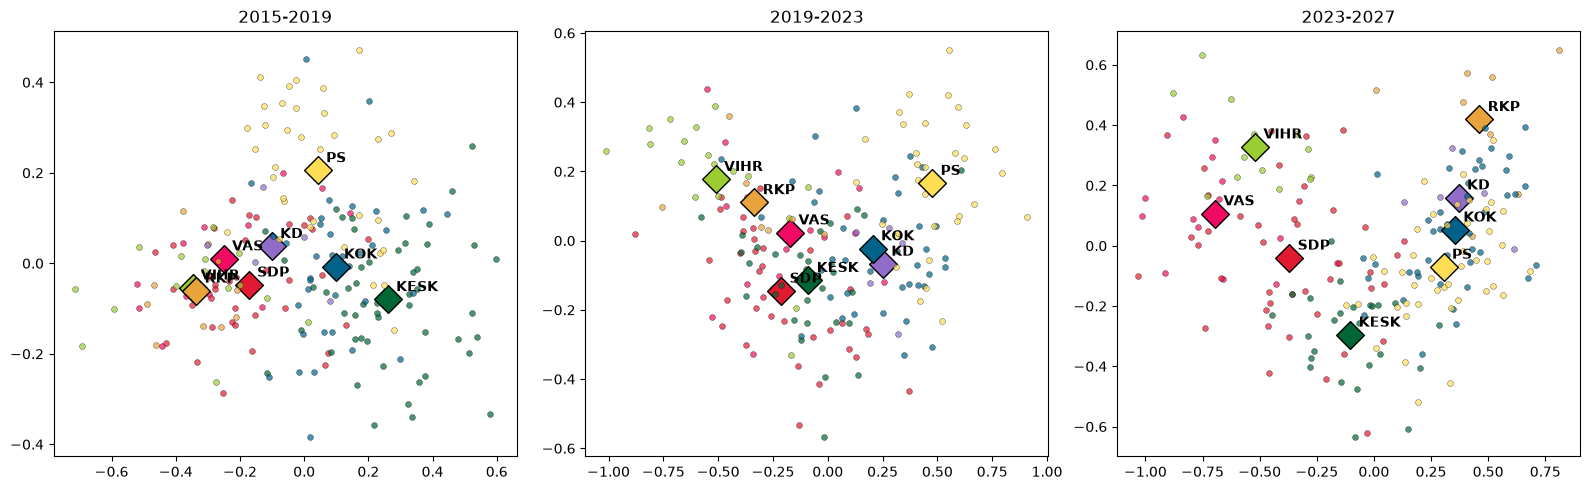

In [14]:
sarakkeet = ["p_" + p for p in PUOLUEET]

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for i, kausi in enumerate(KAUDET):
    osa = profiilit[profiilit["term"] == kausi]
    edustajat = osa.groupby(["person_id", "label"])[sarakkeet].mean().reset_index()

    # log-suhteet ja pääkomponentit
    log_p = np.log(edustajat[sarakkeet].values)
    log_p = log_p - log_p.mean(axis=1, keepdims=True)
    log_p = log_p - log_p.mean(axis=0)
    u, s, vt = np.linalg.svd(log_p, full_matrices=False)
    koordinaatit = log_p @ vt[:2].T

    for puolue in PUOLUEET:
        rivit = (edustajat["label"] == puolue).to_numpy()
        ax[i].scatter(koordinaatit[rivit, 0], koordinaatit[rivit, 1], s=18, alpha=0.7,
                      color=VARIT[puolue], edgecolor="black", linewidth=0.3)
        keskipiste = koordinaatit[rivit].mean(axis=0)
        ax[i].scatter(keskipiste[0], keskipiste[1], s=200, marker="D", color=VARIT[puolue], edgecolor="black")
        ax[i].annotate(puolue, keskipiste, xytext=(6, 6), textcoords="offset points", weight="bold")
    ax[i].set_title(kausi)
plt.tight_layout()
plt.savefig(KUVAT + "tulokset_edustajat.png")
plt.show()

## 5. Yhteenveto

**Päälöydökset** ovat muistion alussa. Kolme tulosta muodostavat yhden kertomuksen: puolueiden kielellinen etäisyys kasvaa, se ei ole pelkkää aihevalintaa, ja se kasvaa, kun eduskunta jakautuu kahdeksi blokiksi.

**Varaumat:**
- Erottuvuus mittaa kielen eroja, ei suoraan kantojen etäisyyttä. Vaalikone tukee yhteyttä kausilla 2019–23 ja 2023–27 (rho 0,47 ja 0,48, ilman RKP:ta 0,60 ja 0,71), mutta ei kaudella 2015–19 (0,08).
- Kolme kautta ja kolme eri hallitusta: trendiä ja hallituspohjan vaikutusta ei voi erottaa.
- Murre ja alue voivat selittää osan eroista, eli ne ovat mahdollisia sekoittavia tekijöitä ([SfDS 11.7.2](https://lacerbi.github.io/stats-for-ds-website/chapters/11-causal-inference.html#confounding-variables)); vakiointi on tekemättä.
- KD:n ja RKP:n tulokset ovat epävarmoja pienen edustajamäärän takia.

## Liite: Siniset 2015–2019

Siniset erosivat PS:stä kesäkuussa 2017. Muistion 05 ajossa 4 ne ovat mukana yhdeksäntenä puolueena. Ne ovat puheissaan lähimpänä KOK:ta (0,20) ja PS:ää (0,21).

In [15]:
siniset = pd.read_csv(TULOKSET + "party_blue_pairwise.csv")
siniset = siniset[siniset["series"] == "real"]
sinisten_parit = siniset[(siniset["a"] == "SIN") | (siniset["b"] == "SIN")]
tulos = sinisten_parit.groupby(["a", "b"])["d"].mean().sort_values().round(3)
print("Sinisten erottuvuus muista puolueista (pienempi = samankaltaisempi):")
tulos

Sinisten erottuvuus muista puolueista (pienempi = samankaltaisempi):


a     b  
KOK   SIN    0.188
SIN   PS     0.215
KESK  SIN    0.373
KD    SIN    0.387
VAS   SIN    0.401
SDP   SIN    0.464
VIHR  SIN    0.520
RKP   SIN    0.641
Name: d, dtype: float64